# Análisis de Enlaces de Hidrógeno — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx hbond`  
**Temperaturas simuladas:** 298 K y 400 K

**Archivos analizados:**

| Archivo | Tipo | Descripción |
|---|---|---|
| `hbond-inter-num-{298,400}.xvg` | Intermolecular | N.º de H-bonds proteína–solvente vs tiempo |
| `hbond-intra-num-{298,400}.xvg` | Intramolecular | N.º de H-bonds dentro de la proteína vs tiempo |
| `hbond-inter-hx-{298,400}.xvg` | Intermolecular | H-bonds n–n+i (residuo–residuo) |
| `hbond-intra-hx-{298,400}.xvg` | Intramolecular | H-bonds n–n+i (residuo–residuo) |

**Parámetros de `gmx hbond`:**  
Ángulo de corte: 120° · Radio de corte: 0.18 nm (H–Aceptor) · `-nonitacc`

---

## 1. Importación de librerías y configuración de estilo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import sem

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# Columnas de los archivos -num: tiempo (ps), nº H-bonds, nº pares
COLS_NUM = ['time_ps', 'n_hbonds', 'n_pairs']
# Columnas de los archivos -hx: tiempo (ps) + n-n+0 … n-n+6
COLS_HX  = ['time_ps', 'nn0', 'nn1', 'nn2', 'nn3', 'nn4', 'nn5', 'nn6']

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [2]:
def load_xvg(filepath, col_names):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#')."""
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    df = pd.DataFrame(data, columns=col_names)
    return df

# ── Intermoleculares (proteína – solvente) ─────────────────────────────────────
df_inter_298 = load_xvg('hbond-inter-num-298.xvg', COLS_NUM)
df_inter_400 = load_xvg('hbond-inter-num-400.xvg', COLS_NUM)

# ── Intramoleculares (dentro de la proteína) ──────────────────────────────────
df_intra_298 = load_xvg('hbond-intra-num-298.xvg', COLS_NUM)
df_intra_400 = load_xvg('hbond-intra-num-400.xvg', COLS_NUM)

print('Archivos cargados:')
for label, df in [('Inter 298 K', df_inter_298), ('Inter 400 K', df_inter_400),
                   ('Intra 298 K', df_intra_298), ('Intra 400 K', df_intra_400)]:
    print(f'  {label:12s} → {len(df)} frames, '
          f't = {df.time_ps.min():.3f} – {df.time_ps.max():.3f} ps, '
          f'⟨n_HB⟩ = {df.n_hbonds.mean():.3f}')

df_inter_298.head(3)

Archivos cargados:
  Inter 298 K  → 2001 frames, t = 0.000 – 2.000 ps, ⟨n_HB⟩ = 3.190
  Inter 400 K  → 2001 frames, t = 0.000 – 2.000 ps, ⟨n_HB⟩ = 2.259
  Intra 298 K  → 2001 frames, t = 0.000 – 2.000 ps, ⟨n_HB⟩ = 0.000
  Intra 400 K  → 2001 frames, t = 0.000 – 2.000 ps, ⟨n_HB⟩ = 0.133


,time_ps,n_hbonds,n_pairs
0,0.000,5.0,0.0
1,0.001,5.0,0.0
2,0.002,5.0,0.0


## 3. Comparativa apilada — H-bonds intermoleculares: 298 K vs 400 K

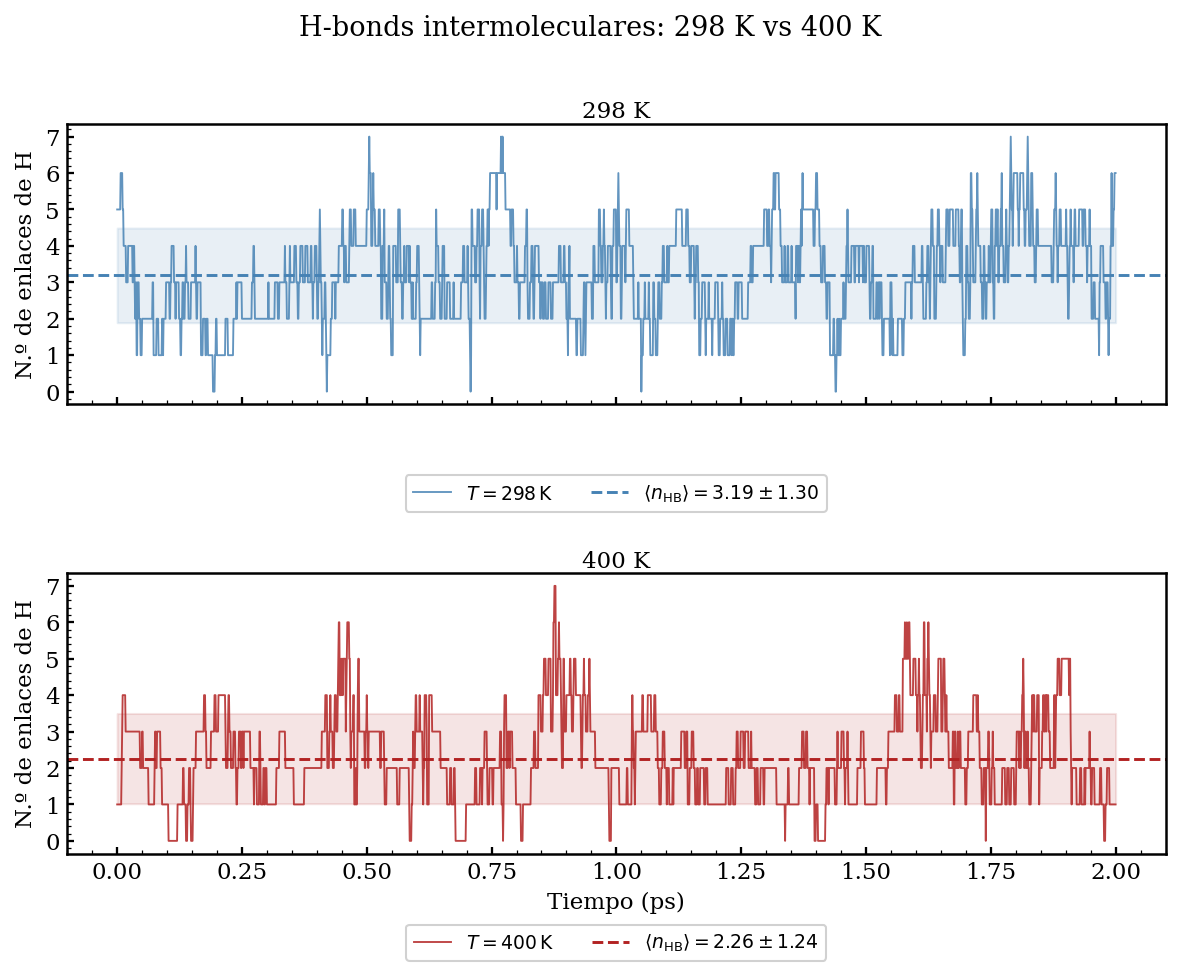

Figura guardada como hbond_inter_comparison_stacked.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)

for ax, df, T, col in zip(axes,
                           [df_inter_298, df_inter_400],
                           ['298', '400'],
                           ['steelblue', 'firebrick']):
    mean_val = df['n_hbonds'].mean()
    std_val  = df['n_hbonds'].std()

    ax.plot(df['time_ps'], df['n_hbonds'], color=col, lw=0.9, alpha=0.85,
            label=rf'$T = {T}\,\mathrm{{K}}$')
    ax.axhline(mean_val, color=col, lw=1.4, ls='--',
               label=rf'$\langle n_{{\mathrm{{HB}}}} \rangle = {mean_val:.2f} \pm {std_val:.2f}$')
    ax.fill_between(df['time_ps'],
                    mean_val - std_val, mean_val + std_val,
                    color=col, alpha=0.12)

    ax.set_ylabel(r'N.º de enlaces de H', fontsize=11)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_title(f'{T} K', fontsize=11, pad=3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)

axes[-1].set_xlabel('Tiempo (ps)', fontsize=11)
fig.suptitle('H-bonds intermoleculares: 298 K vs 400 K', fontsize=13, y=1.01)
fig.align_ylabels()

plt.tight_layout()
plt.savefig('hbond_inter_comparison_stacked.png')
plt.show()
print('Figura guardada como hbond_inter_comparison_stacked.png')

## 4. Resumen estadístico completo

In [10]:
final_rows = []
for df, T, tipo in [(df_inter_298, 298, 'Intermolecular'),
                     (df_inter_400, 400, 'Intermolecular'),
                     (df_intra_298, 298, 'Intramolecular'),
                     (df_intra_400, 400, 'Intramolecular')]:
    n = df['n_hbonds']
    frac = (n > 0).mean() * 100
    final_rows.append({
        'Tipo':               tipo,
        'T (K)':              T,
        '⟨n_HB⟩':            round(n.mean(), 3),
        'σ(n_HB)':            round(n.std(),  3),
        'SEM':                round(sem(n),    4),
        'Min':                int(n.min()),
        'Max':                int(n.max()),
        'Frames con HB (%)': round(frac, 1),
    })

final_df = pd.DataFrame(final_rows)

(final_df.style
    .format({
        '⟨n_HB⟩':            '{:.3f}',
        'σ(n_HB)':            '{:.3f}',
        'SEM':                '{:.4f}',
        'Frames con HB (%)': '{:.1f}',
    })
    .set_caption('Tabla 1. Resumen estadístico de los enlaces de hidrógeno a 298 K y 400 K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T (K)'])
    .hide(axis='index')
)

Tipo,T (K),⟨n_HB⟩,σ(n_HB),SEM,Min,Max,Frames con HB (%)
Intermolecular,298,3.190,1.299,0.0290,0,7,99.6
Intermolecular,400,2.259,1.238,0.0277,0,7,95.9
Intramolecular,298,0.000,0.000,0.0000,0,0,0.0
Intramolecular,400,0.133,0.340,0.0076,0,1,13.3
